In [90]:
# Завдання 1
# У цьому завданні вам потрібно завантажити ось цей датасет. Тут ви знайдете 2 файли - з двовимірним датасетом та датасетом mnist. 
# Для кожного з них застосуйте алгоритм K-means для кластеризації. Щоб знайти оптимальну кількість кластерів, скористайтесь ліктевим методом.

In [110]:
# Завдання 2
# Візуалізуйте результат роботи кластеризації. 
# Для випадку з mnist датасетом, вам потрібно ще скористатись алгоритмом PCA щоб зменшити розмірність вашим даних до 2-вимірного варіанту.

In [91]:
import pandas as pd
import numpy as np

In [92]:
# первый датасет 2d
df_2d = pd.read_csv('data_2d.csv', header=None) # не брать первую строку в заголовок столбцов
df_2d

,0,1,2
0,0.0,-0.768716,0.460860
1,0.0,2.687848,2.366961
2,0.0,-0.201379,0.470430
3,0.0,0.608496,1.225400
4,0.0,-0.082282,1.137218
...,...,...,...
195,1.0,0.629144,4.378584
196,1.0,-0.723824,5.361801
197,1.0,1.346107,2.333476
198,1.0,3.608219,3.411546


In [93]:
df_2d.columns

Index([0, 1, 2], dtype='int64')

In [94]:
X_2d = df_2d.iloc[:, 1:] # : - взять все строки; 1: - взять столбцы с позиции 1 и дальше.
X_2d

,1,2
0,-0.768716,0.460860
1,2.687848,2.366961
2,-0.201379,0.470430
3,0.608496,1.225400
4,-0.082282,1.137218
...,...,...
195,0.629144,4.378584
196,-0.723824,5.361801
197,1.346107,2.333476
198,3.608219,3.411546


In [95]:
# второй датасет mnist
df_mnist = pd.read_csv('mnist.csv', header=None) # не брать первую строку в заголовок столбцов
df_mnist

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
df_mnist.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

In [97]:
X_mnist = df_mnist.iloc[:, 1:] # : - взять все строки; 1: - взять столбцы с позиции 1 и дальше.
X_mnist

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


[818.7168208014774, 348.9655117484038, 265.57339968903193, 205.51985161122593, 168.19018419554774, 133.74998032744526, 119.00481497380642, 104.52574731179969, 95.05897991726795, 89.74149564045831]


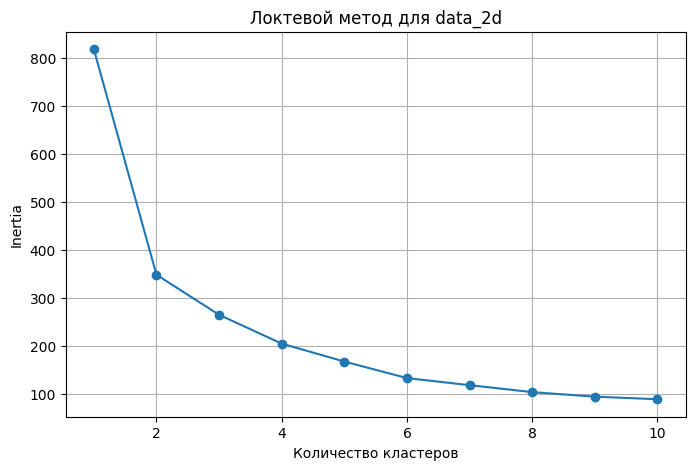

In [98]:
# Ліктевий метод для датасета 2d
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias_2d = [] # Список для хранения ошибок для каждого количества кластеров

K_2d = range(1, 11) # K-means c кластерами от 1 до 10

for k in K_2d:
    kmeans_2d = KMeans(n_clusters=k, random_state=42) # Создание K-means; n_clusters=k — количество кластеров; random_state=42 — фиксирует случайность
    kmeans_2d.fit(X_2d) # Обучение модели
    inertias_2d.append(kmeans_2d.inertia_) # inertia_ насколько далеко точки находятся от центров своих кластеров

print(inertias_2d)

plt.figure(figsize=(8, 5))
plt.plot(K_2d, inertias_2d, marker='o') # marker='o' рисует кружочки в каждой точке
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Локтевой метод для data_2d')
plt.grid(True) # Добавляет сетку
plt.show()

In [99]:
# Висновок:
# За результатами ліктьового методу значення inertia різко зменшується до k=6. 
# Після цього додавання нових кластерів дає значно менший приріст якості кластеризації. 
# Тому оптимальну кількість кластерів обрано рівною 6

In [100]:
# Фінальна кластеризація датасета 2d
kmeans_2d = KMeans(n_clusters=6, random_state=42)
clusters_2d = kmeans_2d.fit_predict(X_2d)
clusters_2d

array([5, 4, 5, 2, 5, 4, 0, 5, 5, 5, 0, 0, 2, 2, 5, 0, 5, 2, 2, 0, 5, 2,
       2, 4, 0, 2, 5, 4, 0, 5, 0, 2, 4, 2, 0, 4, 5, 2, 2, 5, 5, 0, 2, 0,
       2, 0, 5, 2, 2, 0, 2, 2, 5, 2, 2, 5, 0, 4, 2, 4, 0, 0, 5, 0, 0, 5,
       4, 2, 2, 4, 0, 2, 0, 0, 0, 4, 5, 0, 0, 0, 2, 0, 0, 0, 5, 5, 3, 5,
       0, 0, 2, 0, 0, 5, 5, 5, 5, 0, 0, 3, 1, 1, 1, 3, 3, 1, 1, 1, 4, 4,
       1, 4, 2, 1, 4, 3, 4, 4, 4, 1, 1, 1, 4, 3, 1, 3, 4, 1, 2, 3, 4, 1,
       4, 4, 1, 2, 3, 1, 4, 1, 3, 2, 1, 1, 2, 1, 4, 3, 1, 2, 1, 4, 3, 4,
       4, 1, 4, 3, 3, 3, 3, 2, 2, 3, 4, 1, 2, 3, 2, 3, 3, 1, 1, 3, 0, 1,
       3, 1, 3, 4, 3, 4, 3, 3, 3, 3, 1, 4, 1, 3, 1, 1, 1, 1, 1, 3, 3, 2,
       1, 1], dtype=int32)

In [101]:
# добавляем номера кластеров в DataFrame
df_2d['cluster'] = clusters_2d
df_2d

,0,1,2,cluster
0,0.0,-0.768716,0.460860,5
1,0.0,2.687848,2.366961,4
2,0.0,-0.201379,0.470430,5
3,0.0,0.608496,1.225400,2
4,0.0,-0.082282,1.137218,5
...,...,...,...,...
195,1.0,0.629144,4.378584,3
196,1.0,-0.723824,5.361801,3
197,1.0,1.346107,2.333476,2
198,1.0,3.608219,3.411546,1


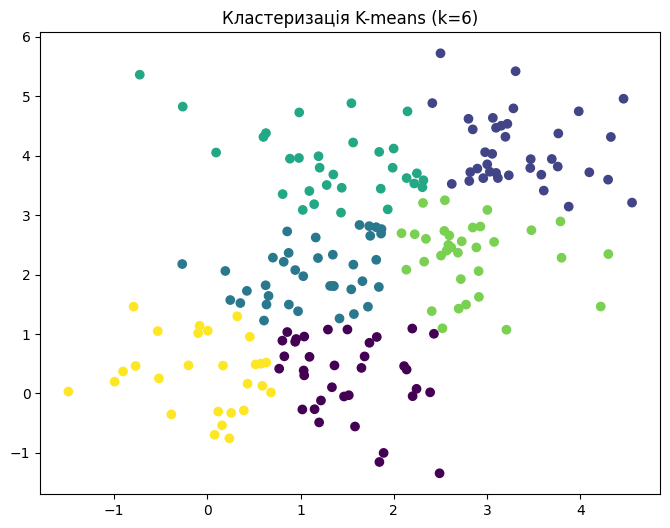

In [102]:
# Визуализация кластеров датасета 2d
plt.figure(figsize=(8, 6))
plt.scatter(
    X_2d.iloc[:, 0],
    X_2d.iloc[:, 1],
    c=clusters_2d, # цвета точек по номерам кластеров
    cmap='viridis' # цветовая схема
)

plt.title('Кластеризація K-means (k=6)')
plt.show()

[1605615688.7939997, 1496033225.5023937, 1444877952.932291, 1351635749.3434176, 1305133084.200979, 1279683303.2565756, 1242837534.057764, 1222305833.4906015, 1201868969.349256, 1175689975.8770285]


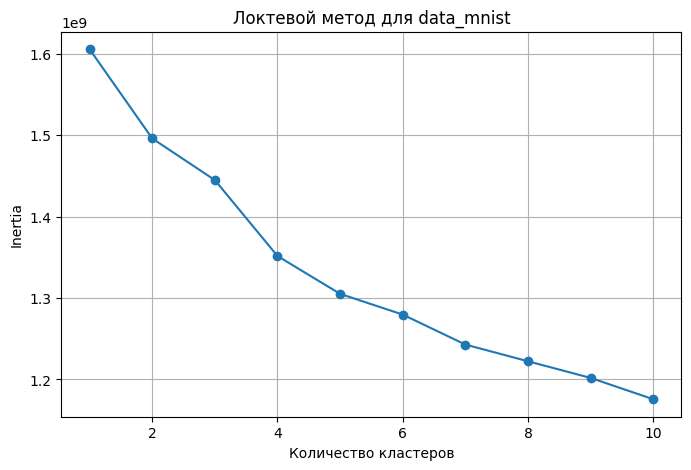

In [103]:
# Ліктевий метод для датасета mnist

inertias_mnist = [] # Список для хранения ошибок для каждого количества кластеров

K_mnist = range(1, 11) # K-means c кластерами от 1 до 10

for k in K_mnist:
    kmeans_mnist = KMeans(n_clusters=k, random_state=42) # Создание K-means; n_clusters=k — количество кластеров; random_state=42 — фиксирует случайность
    kmeans_mnist.fit(X_mnist) # Обучение модели
    inertias_mnist.append(kmeans_mnist.inertia_) # inertia_ насколько далеко точки находятся от центров своих кластеров

print(inertias_mnist)

plt.figure(figsize=(8, 5))
plt.plot(K_mnist, inertias_mnist, marker='o') # marker='o' рисует кружочки в каждой точке
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Локтевой метод для data_mnist')
plt.grid(True) # Добавляет сетку
plt.show()

In [104]:
# Висновок:
# Для датасету MNIST графік ліктьового методу не має чітко вираженої точки перегину. 
# Значення inertia зменшується поступово зі збільшенням кількості кластерів, тому однозначно визначити оптимальну кількість кластерів складно. 
# Для подальшої кластеризації було обрано k=5 як компромісне значення.

In [105]:
# Фінальна кластеризація датасета mnist
kmeans_mnist = KMeans(n_clusters=5, random_state=42)
clusters_mnist = kmeans_mnist.fit_predict(X_mnist)
clusters_mnist

array([3, 1, 2, 4, 3, 2, 3, 3, 1, 3, 4, 4, 3, 4, 2, 0, 3, 3, 0, 3, 2, 1,
       1, 0, 3, 4, 3, 3, 4, 2, 0, 2, 0, 4, 1, 1, 3, 2, 1, 2, 2, 3, 3, 2,
       2, 0, 2, 1, 3, 3, 1, 0, 0, 0, 1, 0, 3, 2, 3, 2, 3, 1, 3, 1, 3, 3,
       1, 3, 0, 4, 3, 4, 1, 2, 2, 2, 0, 3, 2, 3, 3, 1, 1, 3, 3, 3, 2, 0,
       1, 2, 0, 1, 2, 0, 2, 3, 2, 2, 1, 3, 1, 4, 0, 3, 3, 3, 1, 2, 3, 3,
       0, 2, 2, 3, 2, 2, 3, 3, 3, 1, 0, 1, 3, 1, 3, 3, 4, 3, 0, 0, 1, 1,
       0, 3, 0, 2, 4, 2, 1, 3, 2, 3, 0, 2, 3, 2, 3, 1, 4, 2, 3, 3, 2, 0,
       2, 0, 1, 4, 0, 2, 3, 1, 0, 3, 1, 0, 3, 2, 2, 3, 3, 1, 0, 0, 1, 2,
       2, 0, 2, 0, 2, 0, 2, 4, 0, 3, 1, 0, 4, 2, 2, 2, 4, 3, 4, 2, 2, 1,
       3, 1, 0, 1, 2, 2, 2, 0, 3, 0, 1, 3, 3, 2, 3, 2, 3, 4, 0, 2, 2, 0,
       3, 1, 1, 3, 2, 1, 0, 3, 2, 2, 1, 2, 0, 3, 2, 3, 1, 1, 3, 2, 0, 0,
       1, 3, 2, 2, 4, 1, 3, 1, 3, 2, 3, 0, 3, 3, 1, 2, 1, 4, 3, 2, 3, 2,
       3, 2, 0, 2, 0, 4, 0, 4, 2, 3, 3, 3, 2, 0, 1, 2, 1, 3, 2, 2, 3, 1,
       1, 3, 2, 0, 3, 1, 3, 1, 4, 3, 4, 4, 1, 0, 2,

In [107]:
# добавляем номера кластеров в DataFrame
df_mnist['cluster'] = clusters_mnist
df_mnist

,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,784,cluster
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [108]:
# для визуализации кластеров делаем понижение размерности до 2 признаков с помощью PCA.
# Сжать 784 признака до двух новых признаков, сохранив как можно больше информации

from sklearn.decomposition import PCA

# Уменьшаем размерность 784 -> 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_mnist)

X_pca

array([[-2.80486314e+02,  4.49276064e+02],
       [-7.18965803e+01, -1.04577219e+03],
       [-9.67814311e+02, -3.48404490e+02],
       [ 1.05444070e+03, -3.53080130e+02],
       [ 4.19035629e+02,  6.73071273e+02],
       [-1.00108965e+03, -3.07086692e+02],
       [-6.25185620e+01,  4.24906100e+02],
       [-1.71805323e+02,  4.31911058e+02],
       [ 1.83551381e+02,  1.73268054e+02],
       [ 9.03233506e+01,  5.56265417e+02],
       [ 9.52889727e+02, -1.00679591e+03],
       [ 3.60422221e+02, -3.30777858e+02],
       [ 3.26802189e+00,  9.38911588e+02],
       [ 1.08169439e+03, -3.53666745e+02],
       [-1.11412097e+03, -4.16229479e+02],
       [ 1.54833714e+02, -6.37222069e+02],
       [ 4.01432059e+02,  9.30951039e+02],
       [-4.36798872e-01,  3.95263648e+02],
       [ 1.41970703e+02, -4.59313610e+02],
       [ 5.61903206e+01,  7.65661789e+02],
       [-2.65474674e+02,  3.43571817e+02],
       [ 3.14990634e+02, -1.20800037e+02],
       [-2.11032542e+01,  1.66117005e+02],
       [-8.

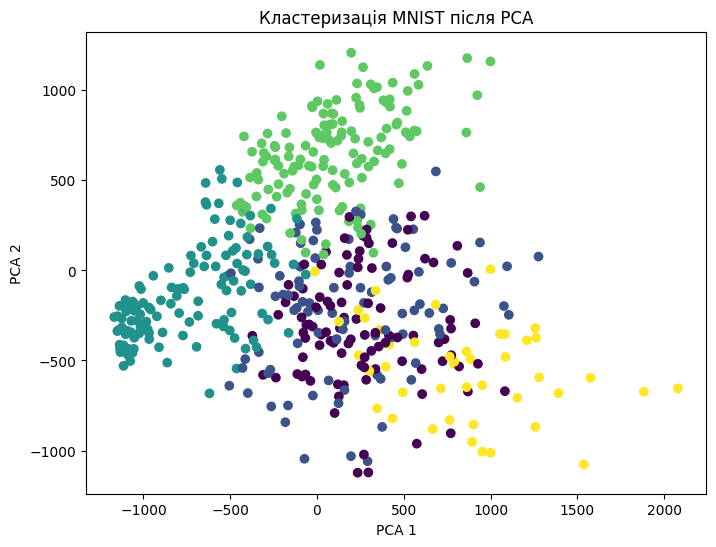

In [109]:
# Визуализация кластеров после PCA для датасета mnist
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_mnist, # цвета точек по номерам кластеров
    cmap='viridis' # цветовая схема
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Кластеризація MNIST після PCA')
plt.show()